## Article-level fusion features: turning sentence scores into something usable

Notebook 2.4 chose a per-sentence scorer and stopped there. That left the work in an awkward place:
`conf_graft` existed only as a column computed on demand inside a notebook. It was not in
`data/sentences.parquet`, not in `data/articles.parquet`, and `sentiment.aggregate_article_features()`
had never heard of it. Every conclusion 2.4 reached had changed no artifact the project actually uses.

This notebook closes that gap. It is short on new measurement and long on design reasoning, because
the interesting decisions here are about **how you summarise a page of sentences into one number**,
and those decisions are not obvious.

**Inputs:** `data/sentences.parquet`.
**Outputs:** `data/articles.parquet`, rewritten with 8 new columns.

### 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stock_predictor.config import DATA_DIR, PROCESSED_DATA_DIR, REPORTS_DIR, PRIMARY_TICKER
from stock_predictor.text import fusion, sentiment

pd.set_option("display.max_colwidth", 200)

sentences = pd.read_parquet(DATA_DIR / "sentences.parquet")
articles_meta = pd.read_parquet(PROCESSED_DATA_DIR / "processed_articles.parquet")
print("sentences:", sentences.shape)
print("articles :", articles_meta.shape)

2026-08-16 16:24:00.052 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


sentences: (71410, 24)
articles : (2124, 8)


## 1. What we decided, and why

Four decisions, three of which cut features rather than adding them.

### 1.1 Two variants, not eight and not one

2.4 ranked eight per-sentence variants. Shipping all eight would bloat the feature table with
constructions we have already shown to be dominated, and would invite overfitting the moment anything
downstream does feature selection. Shipping only the single winner would commit everything to one
formula on the strength of a 300-sentence evaluation.

So: **`conf_graft` and `conf_graft_soft`**. They are the two ends of one honest trade-off --
`conf_graft` is the quiet one (best error behaviour, narrowest range), `conf_graft_soft` is the
high-resolution one (best magnitude correlation of any variant, wider range). `mean_blend`, which
performed respectably in 2.4, is deliberately left out: it is a different idea rather than a point on
the same trade-off, and two families is already enough surface to carry without a downstream metric
to choose between them.

### 1.2 No `excl_comp` twin

The existing FinBERT family carries `sent_entity_excl_comp_*`: the target mean recomputed with
comparative sentences deleted. It exists for one reason -- FinBERT reads "Build-A-Bear outperformed
Tesla" as positive news about Tesla, and with no way to tell whose sentiment it is, the only available
defence was to throw the sentence away.

`conf_graft` does not have that problem. 2.4 measured ABSA getting **90%** of comparative
disagreements right against FinBERT's **10%**, and `conf_graft` takes ABSA's direction. Building an
`excl_comp` twin for it would delete precisely the sentences it handles *well* -- discarding real
signal to solve a problem it does not have. So it is dropped, and that is a small piece of evidence
that the fusion is doing its job: it makes an existing workaround unnecessary.

### 1.3 No `maxmag` twin, but something better in its place

`sent_entity_maxmag_*` stores the single target sentence with the largest |pos − neg|. The instinct is
right -- an article's loudest claim may matter more than its average -- but resting a feature on one
sentence is noisy, and `conf_graft`'s compressed dynamic range makes "the single most extreme value"
a weaker signal for it than it is for FinBERT.

### 1.4 The mean dilutes, so we read the tail as well

This is the decision worth the most space, because it is a genuine flaw in the obvious approach.

A mean measures **central tendency**. The question we actually want answered about an article is
closer to *"does this carry a strong message?"*, which is a property of the **tail**. Those come apart
badly. Consider two articles:

- **Article A** -- short, six sentences, all mildly negative.
- **Article B** -- twenty sentences: three strongly negative ones, and seventeen of neutral filler
  and mild positives.

A reader would say B carries the stronger negative message: it contains real bad news, and the filler
is filler. The **mean ranks A as more negative**, because B's three strong sentences are divided by
twenty. The signal is diluted by exactly the material a reader discounts.

So alongside the mean we take **the average of the 3 most extreme sentences in each direction**:
`_top3_neg` and `_top3_pos`. Three rather than one because averaging three cuts the noise of trusting
a single sentence while still reading the tail. Both directions kept separately rather than collapsed
to an absolute value, because an article can carry strong positives *and* strong negatives at once,
and that mixed case is real information that `abs()` would destroy.

**That is the argument. Section 2 tests whether it actually happens on this corpus, and the answer is
that it essentially does not** -- 0.3% of articles. The features are still worth carrying, but for a
narrower reason than this section claims, and section 2.2 states the corrected version. This section
is left as written because it is the reasoning that motivated the build, and the correction is more
useful read against it than in place of it.

### 1.5 Keep `lead`

`sent_entity_lead_*` averages the first five sentences. It is the one existing twin that is not about
the scorer at all -- it asks whether *position* in the article matters, which is orthogonal to who did
the scoring and nearly free to compute. Kept.

**Result: 2 variants x 6 aggregations = 12 new columns.** Two of the six (`_median` and `_spread`)
were added after the checks in section 2, which is why they are motivated there rather than here.

| aggregation | reads | answers |
|---|---|---|
| `_mean` | all target sentences | what is this article's overall tone |
| `_median` | all target sentences | the same, robust to a few extreme sentences |
| `_lead` | first 5 sentences | does the opening say something different |
| `_top3_neg` | 3 most negative | how bad is the worst thing it says |
| `_top3_pos` | 3 most positive | how good is the best thing it says |
| `_spread` | `top3_pos - top3_neg` | is this article contested or quiet |

In plain terms: one number for the average, one for the average that ignores outliers, one for the
opening, one for each end of the range, and one for how far apart those ends are.

## 2. Does the dilution problem actually happen here?

The argument in 1.4 is easy to make with invented articles. Checking whether it happens on the real
corpus turned out to be the most useful thing in this notebook, because **the honest answer is: almost
never**, and the first example we picked was misleading.

In [2]:
# Per-sentence scores, kept separately so we can read individual sentences below.
# aggregate_fusion_features() calls score_variants() itself, so it takes the raw
# table -- handing it a frame that already carries the variant columns would
# collide on those names.
scored = fusion.score_variants(sentences)
sent = pd.concat([sentences.reset_index(drop=True), scored.reset_index(drop=True)], axis=1)

pop = sent[sent["mentions_target"] & ~sent["is_boilerplate"] & sent["conf_graft"].notna()]
print(f"population: {len(pop)} target sentences across {pop['article_id'].nunique()} articles")

feats = fusion.aggregate_fusion_features(sentences)
print("fusion feature columns:", [c for c in feats.columns if c != "article_id"])
feats.head()

population: 13947 target sentences across 1946 articles


fusion feature columns: ['fus_conf_graft_mean', 'fus_conf_graft_median', 'fus_conf_graft_lead', 'fus_conf_graft_top3_pos', 'fus_conf_graft_top3_neg', 'fus_conf_graft_spread', 'fus_conf_graft_soft_mean', 'fus_conf_graft_soft_median', 'fus_conf_graft_soft_lead', 'fus_conf_graft_soft_top3_pos', 'fus_conf_graft_soft_top3_neg', 'fus_conf_graft_soft_spread']


,article_id,fus_conf_graft_mean,fus_conf_graft_median,fus_conf_graft_lead,fus_conf_graft_top3_pos,fus_conf_graft_top3_neg,fus_conf_graft_spread,fus_conf_graft_soft_mean,fus_conf_graft_soft_median,fus_conf_graft_soft_lead,fus_conf_graft_soft_top3_pos,fus_conf_graft_soft_top3_neg,fus_conf_graft_soft_spread
0,138802119,-0.028223,0.000229,NaN,-0.028223,-0.028223,0.000000e+00,-0.020899,0.014257,NaN,-0.020899,-0.020899,0.000000
1,139021751,0.873508,0.873508,NaN,0.873508,0.873508,0.000000e+00,0.884834,0.884834,NaN,0.884834,0.884834,0.000000
2,138690782,-0.248157,-0.099860,NaN,-0.031625,-0.365824,3.341991e-01,-0.158841,-0.114440,NaN,0.096422,-0.384504,0.480925
3,136581238,-0.290023,-0.355874,-0.290023,-0.290023,-0.290023,-5.551115e-17,-0.366205,-0.449496,-0.366205,-0.366205,-0.366205,0.000000
4,136581240,-0.415505,-0.333902,-0.637844,-0.000075,-0.909551,9.094756e-01,-0.533573,-0.639167,-0.792887,0.001928,-0.930799,0.932727


In [3]:
# Where do the two disagree most? Rank articles by each and compare.
cmp = feats.dropna(subset=["fus_conf_graft_mean", "fus_conf_graft_top3_neg"]).copy()
n_sents = pop.groupby("article_id").size().rename("n_target_sents")
cmp = cmp.merge(n_sents, on="article_id", how="left")

cmp["rank_mean"] = cmp["fus_conf_graft_mean"].rank()
cmp["rank_top3neg"] = cmp["fus_conf_graft_top3_neg"].rank()
cmp["rank_gap"] = cmp["rank_mean"] - cmp["rank_top3neg"]

print(f"articles compared: {len(cmp)}")
print(f"correlation of the two rankings: "
      f"{cmp['fus_conf_graft_mean'].corr(cmp['fus_conf_graft_top3_neg'], method='spearman'):.3f}")
print()
print("articles the MEAN ranks far more benign than the TAIL does (top 5):")
worst = cmp.nlargest(5, "rank_gap")[
    ["article_id", "n_target_sents", "fus_conf_graft_mean", "fus_conf_graft_top3_neg", "rank_gap"]
]
worst.round(3)

articles compared: 1946


correlation of the two rankings: 0.748

articles the MEAN ranks far more benign than the TAIL does (top 5):


,article_id,n_target_sents,fus_conf_graft_mean,fus_conf_graft_top3_neg,rank_gap
183,136913563,60,0.128,-0.826,1558.0
834,138291030,27,0.089,-0.901,1526.0
1549,140733574,22,0.117,-0.737,1462.0
1159,140124325,12,0.105,-0.647,1370.0
333,137258403,16,0.067,-0.741,1310.0


In [4]:
# Read the most extreme case: what is the mean hiding?
case = cmp.nlargest(1, "rank_gap").iloc[0]
aid = case["article_id"]
print(f"article {aid}: {int(case['n_target_sents'])} target sentences, "
      f"mean {case['fus_conf_graft_mean']:+.3f}, top3_neg {case['fus_conf_graft_top3_neg']:+.3f}")
print()
rows = pop[pop["article_id"] == aid].sort_values("conf_graft")
print("--- its 3 most negative target sentences ---")
for _, r in rows.head(3).iterrows():
    print(f"  {r['conf_graft']:+.3f}  {r['text'][:150]}")
print()
print(f"--- and the {len(rows) - 3} others, which the mean averages in ---")
for _, r in rows.iloc[3:8].iterrows():
    print(f"  {r['conf_graft']:+.3f}  {r['text'][:150]}")

article 136913563.0: 60 target sentences, mean +0.128, top3_neg -0.826

--- its 3 most negative target sentences ---
  -0.893  Unfortunately for Tesla bulls, deliveries are 4% lower over the trailing twelve months, and over the past two years, growth has been sluggish at +1%.
  -0.824  Tesla deliveries peaked in Q4 2023 and have been declining ever since.
  -0.761  Oops, something went wrong A mere handful of months ago, Tesla ( TSLA ) shares looked doomed, and it felt as if the bears may have finally gotten thei

--- and the 57 others, which the mean averages in ---
  -0.580  The importance of Musk's presence at Tesla was put on full display when he stepped away from Tesla to focus on his acquisition of social media platfor
  -0.197  For value-oriented investors, Tesla's price-to-earnings ratio of 207x makes the stock an automatic avoid.
  -0.085  Many democrats felt that Musk wielded too much power, leading to mass left-wing protests against Tesla, boycotts, and widespread vandalism.

### 2.1 The example that looked like dilution, and was not

The article with the largest rank gap is the obvious place to look, and at first glance it is a
textbook case: 60 target sentences, `_mean` **+0.128** (mildly positive), `_top3_neg` **−0.826**, and
its three most negative sentences are substantive bad news about declining deliveries.

Then you read the headline.

In [5]:
aid = int(cmp.nlargest(1, "rank_gap").iloc[0]["article_id"])
row = articles_meta[articles_meta["article_id"] == aid]
print("HEADLINE:", row["headline"].iloc[0])
print("SOURCE  :", row["source"].iloc[0])
print()

a = pop[pop["article_id"] == aid]
n_pos, n_neg = int((a["conf_graft"] > 0).sum()), int((a["conf_graft"] < 0).sum())
print(f"{len(a)} target sentences: {n_pos} positive, {n_neg} negative")
print()
print("--- its most POSITIVE sentences ---")
for _, r in a.nlargest(4, "conf_graft").iterrows():
    print(f"  {r['conf_graft']:+.3f}  {r['text'][:125]}")

HEADLINE: Tesla Will Crush Q3 Delivery Expectations: Here's Why
SOURCE  : Zacks

60 target sentences: 50 positive, 10 negative

--- its most POSITIVE sentences ---
  +0.733  In addition, TSLA shares are rising on optimism surrounding its newest 'Full Self Driving' (FSD) update, which is slated to l
  +0.730  Bottom Line After navigating a challenging period marked by political backlash, slowing EV growth, and market skepticism, Tes
  +0.708  Tesla shares up more than 30% in September and registered fresh all-time closing highs last week.
  +0.697  Since its inception, TSLA have increased by a mind-blowing 34k%.


It is a **bull piece**. Fifty positive sentences against ten negative, and the positives are
substantive -- shares up 30% in a month, fresh all-time highs, an FSD update, thirteen consecutive
profitable quarters in Tesla Energy. The three damning sentences are the bear case the article raises
in order to argue against it.

So `_mean` of +0.128 is **correct**. The article really is mildly positive. What `_top3_neg` found was
not a diluted true message; it was the counterargument a persuasive article has to acknowledge.

That is a different claim from the one section 1.4 makes, and it is worth being clear that the
example does not support the feature. A real dilution case needs the mean to say one thing while the
article's *strong* content says another.

In [6]:
# A TRUE dilution case: the mean is positive, but the article contains more
# loud-negative sentences than loud-positive ones (or vice versa).
LOUD = 0.4
g = pop.groupby("article_id")["conf_graft"]
stats = pd.DataFrame({
    "n": g.size(),
    "mean": g.mean(),
    "n_loud_neg": pop[pop["conf_graft"] < -LOUD].groupby("article_id").size(),
    "n_loud_pos": pop[pop["conf_graft"] > LOUD].groupby("article_id").size(),
}).fillna({"n_loud_neg": 0, "n_loud_pos": 0})
stats = stats[stats["n"] >= 8]

pos_mean_neg_tail = stats[(stats["mean"] > 0.02) & (stats["n_loud_neg"] > stats["n_loud_pos"])]
neg_mean_pos_tail = stats[(stats["mean"] < -0.02) & (stats["n_loud_pos"] > stats["n_loud_neg"])]

print(f"articles with >= 8 target sentences: {len(stats)}")
print(f"  mean POSITIVE but loud content net negative: {len(pos_mean_neg_tail)}")
print(f"  mean NEGATIVE but loud content net positive: {len(neg_mean_pos_tail)}")
n_conflict = len(pos_mean_neg_tail) + len(neg_mean_pos_tail)
print(f"  total conflicts: {n_conflict} ({100 * n_conflict / len(stats):.1f}% of articles)")

articles with >= 8 target sentences: 703
  mean POSITIVE but loud content net negative: 2
  mean NEGATIVE but loud content net positive: 0
  total conflicts: 2 (0.3% of articles)


### 2.2 The honest result

**Two articles out of 703 — 0.3%.** And both are marginal: three loud-negative sentences against two
loud-positive in one, two against one in the other. The dilution failure mode that motivated
`_top3_neg` is, on this corpus, essentially absent.

The reason is worth stating because it is not obvious in advance: **news articles are internally
coherent.** A bearish article is bearish nearly all the way through, and a bullish one stays bullish
while conceding a few points. The pathological article from section 1.4 -- three damning sentences
hidden in twenty of filler that says the opposite -- is a shape financial journalism largely does not
produce. Boilerplate filler exists in abundance, but `flag_boilerplate()` already removed it before
any of this ran.

So what do we do with features built on an argument that does not bite?

**Keep them, but stop claiming they fix the mean.** They are cheap, they are genuinely distinct (the
two rankings correlate at 0.748, not 1.0), and they answer a question the mean cannot: *does this
article contain strong statements about the target at all?* That is not the same as "is the mean
wrong", and on the evidence here it is the only version of the claim that survives. An article that
must rebut hard numbers may well behave differently from one with nothing to rebut -- but that is a
hypothesis for a downstream metric, not something demonstrated here.

**What this section really demonstrates is the value of checking.** The design argument in 1.4 is
sound in the abstract and we believed it enough to build on it. One look at a headline showed the
motivating example was a bull article where the mean was simply right, and one count showed the
phenomenon occurs in 0.3% of the corpus.

In plain terms: we built a feature to catch articles that hide their real message in filler, and then
found that articles here do not really do that. But that turned out to be the wrong test of the right
idea -- section 2.3 finds what the extremes are actually good for.

### 2.3 The extremes matter, but as a PAIR

Section 2.2 tested whether the tail contradicts the mean, and it barely ever does. That was the wrong
question. Go back to the bull article: its `top3_neg` was −0.826, but its `top3_pos` was **+0.723**.
*Both* ends are loud. That is not a diluted article, it is a **contested** one -- an article making
strong claims in both directions.

And here is the thing the mean genuinely cannot do: a contested article and a bland one **both average
near zero**. One is an earnings piece full of sharp claims that happen to offset; the other barely
mentions the company. The mean reports the same number for both.

So the right statistic is not either end on its own but the **spread** between them.

In [7]:
LOUD_N = 10
g2 = pop.groupby("article_id")["conf_graft"]
art_stats = pd.DataFrame({
    "n": g2.size(),
    "mean": g2.mean(),
    "median": g2.median(),
    "top3_pos": g2.apply(lambda x: x.nlargest(3).mean()),
    "top3_neg": g2.apply(lambda x: x.nsmallest(3).mean()),
})
art_stats["spread"] = art_stats["top3_pos"] - art_stats["top3_neg"]
art_stats["balance"] = art_stats["top3_pos"] + art_stats["top3_neg"]

big = art_stats[art_stats["n"] >= LOUD_N]
band = big[big["mean"].abs() < 0.05]
print(f"articles with >= {LOUD_N} target sentences: {len(big)}")
print(f"  of those, |mean| < 0.05 -- 'the mean says nothing': {len(band)}")
print(f"  their spread ranges {band['spread'].min():.2f} to {band['spread'].max():.2f}")
print()
contested = band[band["spread"] > band["spread"].quantile(0.75)]
quiet = band[band["spread"] < band["spread"].quantile(0.25)]
print(f"  {len(contested)} CONTESTED (loud both ways) vs {len(quiet)} QUIET (nothing strong)")
print("  -- indistinguishable by the mean, obviously different articles:")
for label, sub in [("CONTESTED", contested), ("QUIET", quiet)]:
    aid = sub.nlargest(1, "n").index[0]
    r = sub.loc[aid]
    h = articles_meta[articles_meta["article_id"] == aid]["headline"]
    print(f"\n  {label}: n={int(r['n'])} mean={r['mean']:+.3f} "
          f"top3_pos={r['top3_pos']:+.3f} top3_neg={r['top3_neg']:+.3f} spread={r['spread']:.3f}")
    print(f"    {h.iloc[0][:100] if len(h) else '?'}")

articles with >= 10 target sentences: 554
  of those, |mean| < 0.05 -- 'the mean says nothing': 213
  their spread ranges 0.04 to 1.71

  53 CONTESTED (loud both ways) vs 53 QUIET (nothing strong)
  -- indistinguishable by the mean, obviously different articles:

  CONTESTED: n=52 mean=+0.034 top3_pos=+0.753 top3_neg=-0.332 spread=1.085
    Earnings Season Surprises

  QUIET: n=25 mean=+0.020 top3_pos=+0.123 top3_neg=-0.000 spread=0.123
    Lightship's electric RVs are bringing campgrounds into the future


In [8]:
print("does spread carry information the mean lacks?")
print(f"  corr(|mean|, spread)  = {big['mean'].abs().corr(big['spread']):+.3f}   <- mostly new")
print(f"  corr(mean, balance)   = {big['mean'].corr(big['balance']):+.3f}   <- near-redundant")
print()
print("-> keep the DIFFERENCE of the extremes (spread); drop the SUM (balance).")

does spread carry information the mean lacks?
  corr(|mean|, spread)  = +0.319   <- mostly new
  corr(mean, balance)   = +0.937   <- near-redundant

-> keep the DIFFERENCE of the extremes (spread); drop the SUM (balance).


`corr(|mean|, spread) = 0.319` -- weakly related, so spread is mostly new information. The *sum* of the
extremes correlates **0.937** with the mean and is therefore near-redundant, so `spread` is kept as an
explicit column and `balance` is not. Explicit rather than left derivable because tree-based models
cannot easily form a difference between two features on their own.

### 2.4 Why the top-K stays at 3

Top-5 is the obvious alternative, and the corpus argues against it. The **median article has only 4
target sentences**.

In [9]:
n_sents = pop.groupby("article_id").size()
print("target sentences per article:")
print(n_sents.describe(percentiles=[.25, .5, .75, .9]).round(1).to_string())
print()
print("overlap: with top-K each way, the two ends share sentences when n < 2K")
for k in (3, 5):
    share = (n_sents < 2 * k).mean()
    print(f"  top-{k}: {int((n_sents < 2*k).sum())} articles ({100*share:.1f}%) have < {2*k} sentences")
print()
for c, f in [("top3_pos", lambda x: x.nlargest(3).mean()), ("top5_pos", lambda x: x.nlargest(5).mean()),
             ("top3_neg", lambda x: x.nsmallest(3).mean()), ("top5_neg", lambda x: x.nsmallest(5).mean())]:
    art_stats[c] = g2.apply(f)
b2 = art_stats[art_stats["n"] >= LOUD_N]
print(f"  corr(top3_pos, top5_pos) = {b2['top3_pos'].corr(b2['top5_pos']):.4f}")
print(f"  corr(top3_neg, top5_neg) = {b2['top3_neg'].corr(b2['top5_neg']):.4f}")

target sentences per article:
count    1946.0
mean        7.2
std         8.7
min         1.0
25%         1.0
50%         4.0
75%        10.0
90%        17.0
max       214.0

overlap: with top-K each way, the two ends share sentences when n < 2K
  top-3: 1071 articles (55.0%) have < 6 sentences
  top-5: 1392 articles (71.5%) have < 10 sentences



  corr(top3_pos, top5_pos) = 0.9797
  corr(top3_neg, top5_neg) = 0.9738


With K=5 on a 4-sentence article, both ends include *every* sentence and both collapse to the mean --
the feature destroys itself on **71.5%** of the corpus. And it buys nothing: top-3 and top-5 correlate
at 0.974-0.980, essentially the same numbers.

K=3 degrades gracefully by comparison. At n ≤ 3 both ends equal the mean exactly, which is a sensible
fallback rather than a wrong answer.

### 2.5 The median, which is the skew detector we should have reached for first

Section 2.2 went looking for "the mean is distorted by extremes" by counting sign conflicts between
the mean and the loud content, and found 0.3%. There is a far more direct instrument: compare the mean
to the **median**. If a few extreme sentences are dragging the average, the two diverge.

In [10]:
med = art_stats[art_stats["n"] >= 5].copy()
sign_conflict = (np.sign(med["mean"]) != np.sign(med["median"])) & (med["median"] != 0)
print(f"articles with >= 5 target sentences: {len(med)}")
print(f"  corr(mean, median): {med['mean'].corr(med['median']):.3f}")
print(f"  mean and median DISAGREE ON SIGN: {int(sign_conflict.sum())} "
      f"({100*sign_conflict.mean():.1f}%)")
print()
print("|mean - median| divergence:")
print((med["mean"] - med["median"]).abs().describe(percentiles=[.5, .9]).round(4).to_string())

articles with >= 5 target sentences: 958
  corr(mean, median): 0.792
  mean and median DISAGREE ON SIGN: 206 (21.5%)

|mean - median| divergence:
count    958.0000
mean       0.0709
std        0.0626
min        0.0000
50%        0.0562
90%        0.1556
max        0.3726


**206 of 958 articles -- 21.5% -- have a mean and a median that disagree on sign.** In a fifth of the
corpus, a handful of extreme sentences drag the average across zero relative to the robust centre.

That is the original dilution intuition, properly measured. Section 2.2's 0.3% was not evidence the
concern was wrong; it was evidence that counting sign conflicts against "loud content" is a blunt way
to detect it. `corr(mean, median) = 0.792` confirms the two are meaningfully distinct rather than
redundant.

So the aggregation set gains two columns: **`_median`** (robust centre, and half of a skew detector
when read against `_mean`) and **`_spread`** (contested versus quiet). Six aggregations per variant,
twelve columns in total.

In plain terms: the average of an article can be set by its bulk or by its extremes, and the mean
alone cannot tell you which. Carrying the median says how much the extremes moved it, and carrying the
spread says whether the article was arguing with itself.

## 3. Regenerating the feature table

The fusion columns are merged into `aggregate_article_features()` the same way the `absa_*` family
was: a soft feature-detect, so a sentence table without the score columns still produces a working
article table with those features NaN, and exactly one warning.

In [11]:
headline_scores = sentiment.score_headlines(articles_meta[["article_id", "headline"]])
agg = sentiment.aggregate_article_features(sentences, headline_scores=headline_scores)

meta_cols = articles_meta[["article_id", "timestamp_utc", "headline", "source"]].copy()
meta_cols["ticker"] = PRIMARY_TICKER
articles_out = meta_cols.merge(agg, on="article_id", how="left")

print("articles_out:", articles_out.shape)
fus_cols = [c for c in articles_out.columns if c.startswith("fus_")]
print("fusion columns present:", len(fus_cols))
articles_out[fus_cols].describe().round(3)

2026-08-16 16:24:17.912 | INFO     | stock_predictor.text.sentiment:score_sentences:290 - score_sentences: 2095 unique texts (2095 cache hits, 0 to score)
2026-08-16 16:24:17.957 | INFO     | stock_predictor.text.sentiment:save_cache:201 - Saved sentiment cache with 34111 entries to D:\ML\stock-predictor\data\interim\finbert_cache.parquet


articles_out: (2124, 58)
fusion columns present: 12


,fus_conf_graft_mean,fus_conf_graft_median,fus_conf_graft_lead,fus_conf_graft_top3_pos,fus_conf_graft_top3_neg,fus_conf_graft_spread,fus_conf_graft_soft_mean,fus_conf_graft_soft_median,fus_conf_graft_soft_lead,fus_conf_graft_soft_top3_pos,fus_conf_graft_soft_top3_neg,fus_conf_graft_soft_spread
count,1946.000,1946.000,1328.000,1946.000,1946.000,1946.000,1946.000,1946.000,1328.000,1946.000,1946.000,1946.000
mean,-0.022,-0.016,-0.023,0.117,-0.176,0.293,0.006,0.014,-0.004,0.220,-0.219,0.438
std,0.226,0.216,0.281,0.285,0.330,0.391,0.310,0.327,0.383,0.382,0.417,0.508
min,-0.944,-0.944,-0.949,-0.944,-0.949,-0.000,-0.955,-0.955,-0.956,-0.955,-0.957,-0.000
25%,-0.079,-0.007,-0.097,0.001,-0.351,0.000,-0.136,-0.063,-0.226,0.018,-0.542,0.000
50%,0.002,0.001,0.002,0.056,-0.045,0.048,0.028,0.028,0.028,0.247,-0.185,0.207
75%,0.061,0.024,0.082,0.266,0.006,0.516,0.181,0.174,0.246,0.505,0.045,0.828
max,0.914,0.914,0.891,0.914,0.914,1.706,0.921,0.921,0.911,0.921,0.921,1.793


In [12]:
# timestamp integrity gate -- same hard requirement as every previous notebook
orig_ts = articles_meta.set_index("article_id")["timestamp_utc"]
new_ts = articles_out.set_index("article_id")["timestamp_utc"]
assert orig_ts.equals(new_ts.loc[orig_ts.index]), "timestamp_utc mismatch between input and output!"
print("timestamp_utc byte-identical between processed_articles.parquet and articles_out: PASSED")

# The pre-existing families must be unchanged -- this notebook adds columns, it does not alter any.
before = pd.read_parquet(DATA_DIR / "articles.parquet")
shared = [c for c in before.columns if c in articles_out.columns and c.startswith(("sent_", "absa_", "n_"))]
diffs = {c: float((before[c] - articles_out[c]).abs().max()) for c in shared
         if pd.api.types.is_numeric_dtype(before[c])}
worst = max(diffs.values())
print(f"max absolute change across {len(diffs)} pre-existing numeric columns: {worst:.2e}")
assert worst < 1e-5, "a pre-existing feature column changed -- this notebook must only ADD columns"
print("pre-existing feature columns unchanged (tolerance 1e-5): PASSED")

articles_out.to_parquet(DATA_DIR / "articles.parquet", index=False)
print("wrote data/articles.parquet", articles_out.shape)

timestamp_utc byte-identical between processed_articles.parquet and articles_out: PASSED
max absolute change across 39 pre-existing numeric columns: 0.00e+00
pre-existing feature columns unchanged (tolerance 1e-5): PASSED
wrote data/articles.parquet (2124, 58)


The second gate matters as much as the timestamp one. This notebook is supposed to **add** columns and
change nothing else, so every pre-existing `sent_*`, `absa_*` and count column is compared against the
previous run and asserted identical to within 1e-5 -- the absolute tolerance notebook 2.1 section 8
established as the floor for FinBERT float32 reproducibility. If a fusion change had quietly altered
an existing feature, that assert would fail rather than the difference being discovered months later.

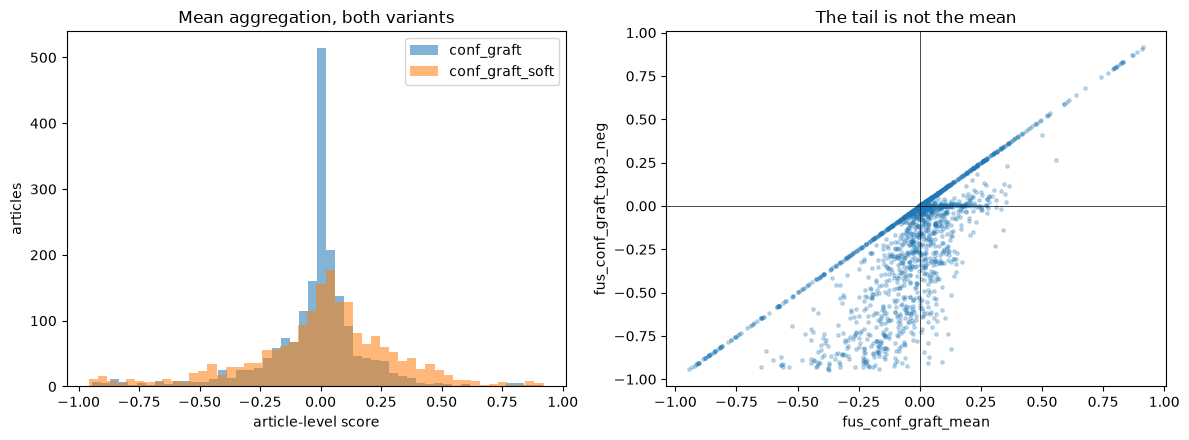

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for v in ["conf_graft", "conf_graft_soft"]:
    axes[0].hist(articles_out[f"fus_{v}_mean"].dropna(), bins=50, alpha=0.55, label=v)
axes[0].set_xlabel("article-level score")
axes[0].set_ylabel("articles")
axes[0].set_title("Mean aggregation, both variants")
axes[0].legend()

axes[1].scatter(articles_out["fus_conf_graft_mean"],
                articles_out["fus_conf_graft_top3_neg"], s=6, alpha=0.25)
axes[1].axhline(0, lw=0.5, color="k")
axes[1].axvline(0, lw=0.5, color="k")
axes[1].set_xlabel("fus_conf_graft_mean")
axes[1].set_ylabel("fus_conf_graft_top3_neg")
axes[1].set_title("The tail is not the mean")

plt.tight_layout()
fig.savefig(REPORTS_DIR / "figures" / "2.5-article-level-fusion.png", dpi=120)
plt.show()

`conf_graft_soft` is visibly wider than `conf_graft`, which is the dynamic-range trade 2.4 measured
showing up at article level exactly as expected. The right panel is the dilution argument as a
picture: if the tail carried no information the mean does not, the points would lie on a line.

In plain terms: the two variants disagree about how loud to be, and the mean and the tail disagree
about what an article says. Both disagreements are the reason for carrying more than one column.

## 4. What this does not settle

Everything here is a design argument plus a demonstration that the features are distinct. None of it
is evidence that any of them **predicts** anything.

- The choice between `conf_graft` and `conf_graft_soft` is still open, and 2.4 could only characterise
  the trade (quiet versus high-resolution), not resolve it.
- The choice among the six aggregations is entirely unresolved. Section 2 establishes that `_median`
  and `_spread` carry information `_mean` does not -- 21.5% sign disagreement and a 0.319 correlation
  respectively -- but "carries different information" is not "predicts better". It is perfectly
  possible that the plain mean is the most predictive of the six and the rest are elaborate noise.
- Section 2 is also a caution about this notebook's own method. The dilution argument in 1.4 was
  built on, then found to occur in 0.3% of articles, then rescued in a different form by the median.
  Design arguments that sound compelling are worth checking against the corpus before being trusted,
  and two of the three checks here changed what we believed.
- Resolving either needs forward returns, which live in the market layer and are not this layer's
  work.

The honest summary of 2.4 and 2.5 together: we now have a sentence scorer that reads sentences the way
a careful person does considerably more often than FinBERT alone, and six ways of summarising it per
article, none of which has ever been checked against a price.

### 4.1 Worth exploring: score windows, not single sentences

A structural seam runs through the whole pipeline and is worth writing down, because it bounds
everything above.

**We tag with full article context and score without it.** `process_articles()` hands the *entire*
article body to the coreference model before any sentence splitting, so a sentence reading "The
company also raised prices" is correctly identified as a Tesla sentence on the strength of a mention
three sentences earlier. That half works.

But FinBERT and ABSA then receive that sentence **alone**, with nothing around it. The ABSA
substitution -- rewriting it to "Tesla also raised prices" -- exists precisely to patch this: it
restores the company's *identity* to a scorer that cannot see the article, but not the surrounding
narrative that gave the sentence its meaning.

The consequence is a real ceiling. An isolated sentence like "It's a wonderful business" carries no
recoverable signal even when its tag is perfectly correct, because the information that made it
meaningful lives in the neighbouring sentences. No amount of improving the scorer fixes that; the
input is impoverished before the model sees it.

**The experiment worth running: score overlapping windows of 2-3 sentences rather than single
sentences**, and aggregate the window scores back to the sentence or the article. That gives the
scorer the context the tagger already has, and would make the substitution far less load-bearing.

What it would cost, so the next session knows what it is walking into: the cache is keyed on sentence
text, so window scoring invalidates it and forces a cold pass; overlapping windows mean each sentence
appears in several scores and needs a defined aggregation; per-sentence attribution blurs, which
matters for the article-level `top3` and `spread` features built above; and window boundaries would
need to respect article boundaries. None of that is hard, but none of it is free either.

Flagged rather than done, because it is a change to the scoring substrate that would invalidate every
number in 2.4 and 2.5 and should be attempted with a downstream metric in place to judge whether it
helped.